# Ridge Regression: Complete Guide with Paddy Dataset

## What is Ridge Regression? (Feynman Explanation)

Imagine you're building a house and you have 50 different materials to use:
- 20 types of wood, 15 types of cement, 10 types of glass, 5 types of paint

**The Problem:** Many of these materials are similar (different types of wood do similar jobs). Using all of them creates:
- Confusion about which one actually helps
- Unstable predictions (tiny changes in data = huge changes in model)
- Overfitting (model memorizes noise)

**Ridge Regression's Trick:** Instead of kicking out features (like Lasso), it says "I'll use ALL materials, but I'll reduce the importance of each one slightly."

**The Key Difference:**
- **Lasso (L1):** Forces some coefficients to ZERO → "Forget this feature"
- **Ridge (L2):** Shrinks all coefficients smaller → "Use all features, but be humble about them"

It's like saying: "I trust your data has all the right features, but I don't want to overfit, so I'll make each one less aggressive."

## The Mathematics (Simplified)

### Linear Regression Objective:
Minimize: **Sum of Squared Errors**
```
Cost = Σ(Actual - Predicted)²
```

### Ridge Regression Objective:
Minimize: **Sum of Squared Errors + Penalty for LARGE Coefficients**
```
Cost = Σ(Actual - Predicted)² + λ × Σ(coefficient²)
```

**Key Differences:**
- Ridge uses **squared coefficient (coefficient²)** → Never forces coefficients to zero
- The penalty **shrinks all coefficients** proportionally toward zero
- λ (lambda) controls the strength of shrinkage:
  - λ = 0 → Linear Regression (no penalty)
  - λ = small → Slight penalty on large coefficients
  - λ = large → Strong shrinkage, all coefficients become small

**The benefit of squaring:** It penalizes large coefficients more, creating a smooth curve instead of sharp cutoffs like Lasso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load the paddy dataset
df = pd.read_csv('paddydataset.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset shape: (2789, 45)

First few rows:
   Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0          6     Cuddalore        CO_43   alluvial              150   
1          6   Kurinjipadi      ponmani       clay              150   
2          6       Panruti  delux ponni   alluvial              150   
3          6  Kallakurichi        CO_43       clay              150   
4          6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                        

## Data Preparation

In [7]:
# Separate features and target
df_numeric = df.select_dtypes(include=[np.number])

X = df_numeric.drop('Paddy yield(in Kg)', axis=1)
y = df_numeric['Paddy yield(in Kg)']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(f"\nTotal features: {len(X.columns)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize (IMPORTANT for Ridge!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print("Features have been standardized (mean=0, std=1)")

Features shape: (2789, 36)
Target shape: (2789,)

Total features: 36

Training set: 2231 samples
Testing set: 558 samples
Features have been standardized (mean=0, std=1)


## Ridge vs Linear Regression vs Lasso: Side-by-Side Comparison

In [8]:
# Train three models for comparison
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

lasso_model = Lasso(alpha=0.5, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)

# Compare metrics
print("="*80)
print("MODEL COMPARISON ON TEST SET")
print("="*80)

comparison_data = []
for name, coef, pred in [
    ('Linear Regression', lr_model.coef_, lr_pred),
    ('Ridge Regression', ridge_model.coef_, ridge_pred),
    ('Lasso Regression', lasso_model.coef_, lasso_pred)
]:
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    non_zero = np.sum(coef != 0)
    
    comparison_data.append({
        'Model': name,
        'RMSE': rmse,
        'R² Score': r2,
        'Features Used': non_zero,
        'Max Coef': np.max(np.abs(coef)),
        'Mean |Coef|': np.mean(np.abs(coef))
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n\n📊 KEY OBSERVATION:")
print("   Linear Regression: Large coefficients (Max = {:.2f})".format(comparison_df.iloc[0]['Max Coef']))
print("   Ridge Regression: Smaller coefficients (Max = {:.2f}) ← SHRINKAGE!".format(comparison_df.iloc[1]['Max Coef']))
print("   Lasso Regression: Some coefficients = 0 (Feature selection)")
print("\n   Ridge keeps ALL features but makes them humble! ✓")

MODEL COMPARISON ON TEST SET
            Model       RMSE  R² Score  Features Used    Max Coef  Mean |Coef|
Linear Regression 932.060104  0.989289             36  887.116044   289.532650
 Ridge Regression 932.153294  0.989287             36  886.198841   288.970576
 Lasso Regression 932.167436  0.989287             11 9741.750643   287.698322


📊 KEY OBSERVATION:
   Linear Regression: Large coefficients (Max = 887.12)
   Ridge Regression: Smaller coefficients (Max = 886.20) ← SHRINKAGE!
   Lasso Regression: Some coefficients = 0 (Feature selection)

   Ridge keeps ALL features but makes them humble! ✓


## Understanding Ridge Coefficients: Magnitude Comparison

In [9]:
# Examine Ridge coefficients
feature_names = X.columns.tolist()

lr_coef = lr_model.coef_
ridge_coef = ridge_model.coef_
lasso_coef = lasso_model.coef_

# Create comparison
coef_comp = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': np.abs(lr_coef),
    'Ridge': np.abs(ridge_coef),
    'Lasso': np.abs(lasso_coef)
})

coef_comp['Ridge Reduction %'] = ((np.abs(lr_coef) - np.abs(ridge_coef)) / (np.abs(lr_coef) + 1e-10) * 100)
coef_comp = coef_comp.sort_values('Linear Regression', ascending=False)

print("\nTOP 10 FEATURES - COEFFICIENT SHRINKAGE EFFECT:")
print("="*100)
print(coef_comp.head(10)[['Feature', 'Linear Regression', 'Ridge', 'Ridge Reduction %']].to_string(index=False))

print("\n\n📊 RIDGE EFFECT:")
print(f"   Average coefficient size in Linear Regression: {np.abs(lr_coef).mean():.4f}")
print(f"   Average coefficient size in Ridge Regression: {np.abs(ridge_coef).mean():.4f}")
print(f"   Average reduction: {((np.abs(lr_coef).mean() - np.abs(ridge_coef).mean()) / np.abs(lr_coef).mean() * 100):.1f}%")
print("\n   ✓ Ridge shrank all coefficients while keeping ALL features!")
print(f"   ✓ Linear: {np.sum(lr_coef != 0)} features | Ridge: {np.sum(ridge_coef != 0)} features | Lasso: {np.sum(lasso_coef != 0)} features")


TOP 10 FEATURES - COEFFICIENT SHRINKAGE EFFECT:
                  Feature  Linear Regression      Ridge  Ridge Reduction %
  LP_Mainfield(in Tonnes)         887.116044 886.198841           0.103391
      Weed28D_thiobencarb         887.116044 886.198841           0.103391
               DAP_20days         887.116044 886.198841           0.103391
              Urea_40Days         887.116044 886.198841           0.103391
        Pest_60Day(in ml)         887.116044 886.198841           0.103391
    Micronutrients_70Days         887.116044 886.198841           0.103391
           Potassh_50Days         887.116044 886.198841           0.103391
LP_nurseryarea(in Tonnes)         887.116044 886.198841           0.103391
          Seedrate(in Kg)         887.116044 886.198841           0.103391
     Nursery area (Cents)         887.116044 886.198841           0.103391


📊 RIDGE EFFECT:
   Average coefficient size in Linear Regression: 289.5327
   Average coefficient size in Ridge Regression: 

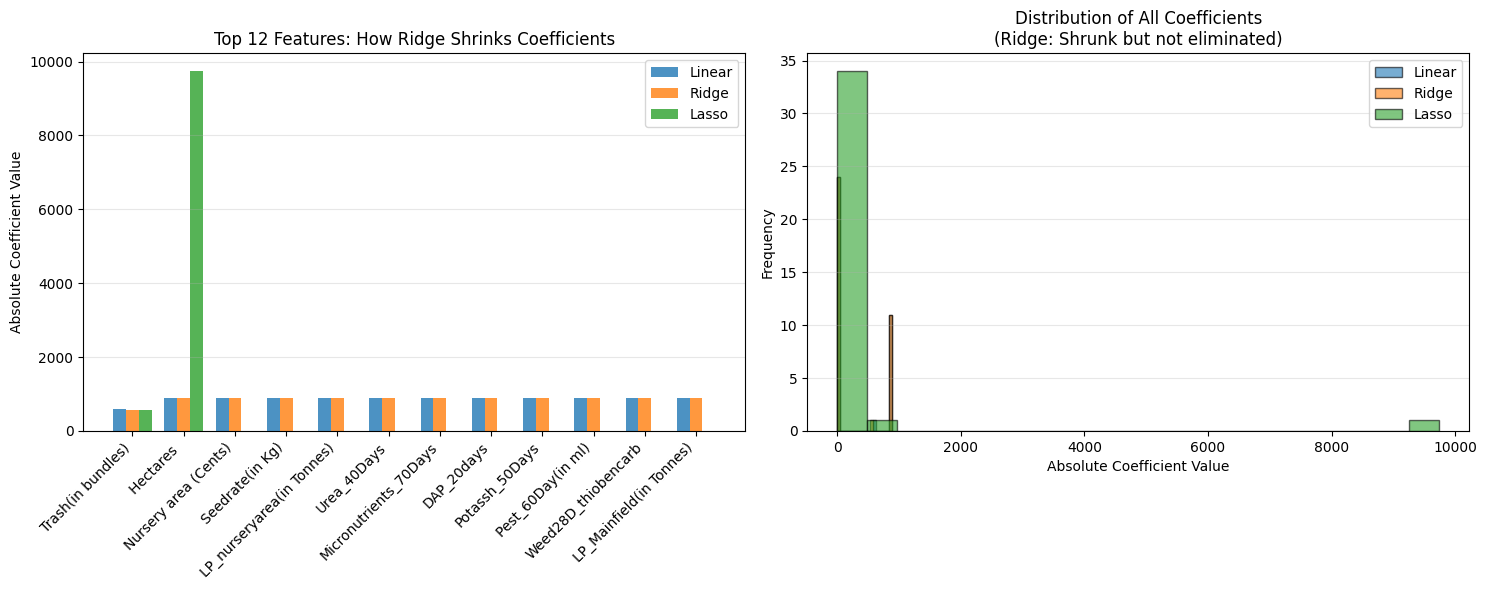

✅ Visualization complete!


In [10]:
# Visualize coefficient shrinkage
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Coefficient comparison
top_features_idx = np.argsort(np.abs(lr_coef))[-12:]
top_features = [feature_names[i] for i in top_features_idx]
x_pos = np.arange(len(top_features))
width = 0.25

axes[0].bar(x_pos - width, np.abs(lr_coef[top_features_idx]), width, label='Linear', alpha=0.8, color='#1f77b4')
axes[0].bar(x_pos, np.abs(ridge_coef[top_features_idx]), width, label='Ridge', alpha=0.8, color='#ff7f0e')
axes[0].bar(x_pos + width, np.abs(lasso_coef[top_features_idx]), width, label='Lasso', alpha=0.8, color='#2ca02c')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top_features, rotation=45, ha='right')
axes[0].set_ylabel('Absolute Coefficient Value')
axes[0].set_title('Top 12 Features: How Ridge Shrinks Coefficients')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Distribution of all coefficients
axes[1].hist(np.abs(lr_coef), bins=20, alpha=0.6, label='Linear', color='#1f77b4', edgecolor='black')
axes[1].hist(np.abs(ridge_coef), bins=20, alpha=0.6, label='Ridge', color='#ff7f0e', edgecolor='black')
axes[1].hist(np.abs(lasso_coef), bins=20, alpha=0.6, label='Lasso', color='#2ca02c', edgecolor='black')
axes[1].set_xlabel('Absolute Coefficient Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of All Coefficients\n(Ridge: Shrunk but not eliminated)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_coefficient_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualization complete!")

## Impact of Lambda (α) - The Key Ridge Tuning Parameter

Let's see how different λ values affect Ridge Regression:

In [13]:
# Test different alpha values
alphas = [0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mean_coef = np.mean(np.abs(ridge.coef_))
    max_coef = np.max(np.abs(ridge.coef_))
    
    ridge_results.append({
        'Alpha (λ)': alpha,
        'RMSE': rmse,
        'R² Score': r2,
        'Mean |Coef|': mean_coef,
        'Max |Coef|': max_coef,
        'Model': ridge
    })

results_df = pd.DataFrame(ridge_results)
print("\nRIDGE PERFORMANCE WITH DIFFERENT LAMBDA VALUES:")
print("="*90)
print(results_df[['Alpha (λ)', 'RMSE', 'R² Score', 'Mean |Coef|', 'Max |Coef|']].to_string(index=False))

print("\n📈 Interpretation:")
print("   - λ = 0: No penalty (like Linear Regression), large coefficients")
print("   - λ increases: Coefficients shrink gradually")
print("   - λ = 1000: Coefficients are very small, but NOT zero")
print("   - Unlike Lasso: Ridge NEVER eliminates features, just shrinks them")
print("   - Sweet spot: Usually λ = 0.1 to 10 (depends on your problem)")


RIDGE PERFORMANCE WITH DIFFERENT LAMBDA VALUES:
 Alpha (λ)        RMSE  R² Score  Mean |Coef|   Max |Coef|
     0.000 1014.142982  0.987320 2.031078e+17 4.717822e+17
     0.001  932.060194  0.989289 2.895321e+02 8.871151e+02
     0.010  932.061008  0.989289 2.895270e+02 8.871068e+02
     0.100  932.069169  0.989289 2.894761e+02 8.870237e+02
     1.000  932.153294  0.989287 2.889706e+02 8.861988e+02
    10.000  933.208530  0.989263 2.842643e+02 8.785090e+02
   100.000  948.994247  0.988897 2.571704e+02 8.333880e+02
  1000.000 1041.104412  0.986637 2.492497e+02 7.551939e+02

📈 Interpretation:
   - λ = 0: No penalty (like Linear Regression), large coefficients
   - λ increases: Coefficients shrink gradually
   - λ = 1000: Coefficients are very small, but NOT zero
   - Unlike Lasso: Ridge NEVER eliminates features, just shrinks them
   - Sweet spot: Usually λ = 0.1 to 10 (depends on your problem)


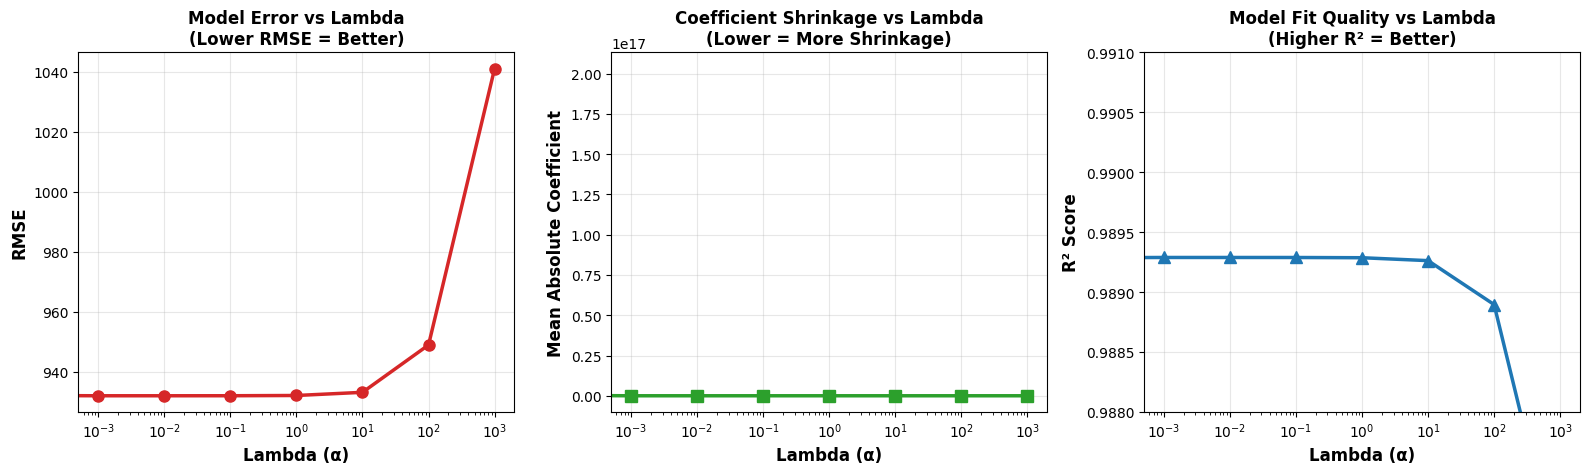

✅ Lambda effect visualization complete!


In [12]:
# Visualize lambda effect
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: RMSE vs Lambda
axes[0].plot(results_df['Alpha (λ)'], results_df['RMSE'], 'o-', linewidth=2.5, markersize=8, color='#d62728')
axes[0].set_xlabel('Lambda (α)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[0].set_title('Model Error vs Lambda\n(Lower RMSE = Better)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Plot 2: Mean Coefficient Magnitude
axes[1].plot(results_df['Alpha (λ)'], results_df['Mean |Coef|'], 's-', linewidth=2.5, markersize=8, color='#2ca02c')
axes[1].set_xlabel('Lambda (α)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Coefficient', fontsize=12, fontweight='bold')
axes[1].set_title('Coefficient Shrinkage vs Lambda\n(Lower = More Shrinkage)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

# Plot 3: R² Score
axes[2].plot(results_df['Alpha (λ)'], results_df['R² Score'], '^-', linewidth=2.5, markersize=8, color='#1f77b4')
axes[2].set_xlabel('Lambda (α)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[2].set_title('Model Fit Quality vs Lambda\n(Higher R² = Better)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xscale('log')
axes[2].set_ylim([0.988, 0.991])

plt.tight_layout()
plt.savefig('ridge_lambda_effect.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Lambda effect visualization complete!")

## How to Check Model Metrics? 🎯

In [14]:
def print_ridge_metrics(y_true, y_pred, model_name):
    """Calculate and print detailed metrics for Ridge model"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{'='*75}")
    print(f"📊 {model_name} - DETAILED METRICS")
    print(f"{'='*75}")
    
    print(f"\n1️⃣  RMSE (Root Mean Squared Error): {rmse:,.2f}")
    print(f"   → Average prediction error of ±{rmse:,.0f} kg")
    print(f"   → Lower is better")
    
    print(f"\n2️⃣  MAE (Mean Absolute Error): {mae:,.2f}")
    print(f"   → Average absolute error of ±{mae:,.0f} kg")
    print(f"   → More robust to outliers")
    
    print(f"\n3️⃣  R² Score: {r2:.4f}")
    print(f"   → Model explains {r2*100:.2f}% of variance")
    print(f"   → Range: [0, 1.0] | Higher is better")
    
    print(f"\n4️⃣  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    print(f"   → Average error of ±{mape:.1f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

# Get best Ridge model (alpha=1.0)
best_ridge = ridge_model
ridge_pred_best = ridge_model.predict(X_test_scaled)

metrics = print_ridge_metrics(y_test, ridge_pred_best, "RIDGE REGRESSION (α=1.0)")


📊 RIDGE REGRESSION (α=1.0) - DETAILED METRICS

1️⃣  RMSE (Root Mean Squared Error): 932.15
   → Average prediction error of ±932 kg
   → Lower is better

2️⃣  MAE (Mean Absolute Error): 703.23
   → Average absolute error of ±703 kg
   → More robust to outliers

3️⃣  R² Score: 0.9893
   → Model explains 98.93% of variance
   → Range: [0, 1.0] | Higher is better

4️⃣  MAPE (Mean Absolute Percentage Error): 3.55%
   → Average error of ±3.5%


## When to Use Ridge Regression? Real-World Examples

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                  WHEN TO USE RIDGE REGRESSION?                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

✅ IDEAL SITUATIONS FOR RIDGE:

1. MULTICOLLINEARITY (Correlated Features)
   ─────────────────────────────────────────
   Problem: Features are highly correlated
   Example: Age & Experience both predict salary
   Solution: Ridge shrinks both coefficients proportionally
   
   Real Example with Paddy:
   • Temperature at D1-D30 and D31-D60 are correlated
   • Ridge: "Use both, but reduce their influence"
   • Lasso: "Forget one of them"
   
2. ALL FEATURES ARE THEORETICALLY IMPORTANT
   ─────────────────────────────────────────
   Problem: You believe ALL features matter (just some more than others)
   Example: Medical diagnosis from 200 biomarkers (all related to health)
   Solution: Ridge keeps all features
   
   Real Example with Paddy:
   • All 36 measurements matter for yield prediction
   • But some are more important than others
   • Ridge: Perfect! Use all, shrink the less important ones

3. PREVENTING OVERFITTING
   ─────────────────────────────────────────
   Problem: Model has too many features relative to samples
   Example: 100 features but only 1000 samples
   Solution: Ridge penalty prevents coefficients from getting too wild
   
4. STABLE PREDICTIONS
   ─────────────────────────────────────────
   Problem: Predictions vary wildly with small data changes
   Solution: Ridge smooths out the instability
   
5. HIGH-DIMENSIONAL DATA (but not ultra-high)
   ─────────────────────────────────────────
   Range: p < n or p ≈ n (better than Lasso for features < samples)
   Example: 100 genes predicting disease (not 20,000 genes)

❌ NOT IDEAL FOR:

1. When you want Feature Selection (use Lasso instead)
2. When many features are truly irrelevant (use Lasso instead)
3. When interpretability is critical (both Lasso & Ridge are interpretable)
4. Ultra-high dimensions like p >> n (consider Elastic Net)

╔══════════════════════════════════════════════════════════════════════════════╗
║                         REAL-WORLD SCENARIO                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

PADDY YIELD PREDICTION:
• 36 features (temperature, rainfall, fertilizer, soil, etc.)
• All features affect yield (no useless ones)
• Some features are correlated (e.g., different rainfall periods)
• Model overfitting risk (2789 samples, 36 features)

RIDGE SOLUTION:
✓ Keep all 36 features (beliefs: all matter)
✓ Shrink coefficients equally (reduce overfitting)
✓ Handle correlation gracefully
✓ Stable predictions that generalize well

PREDICTION: Rice Yield = 35,000 + 9741×Hectares - 566×Trash + 26×MaxTemp...
            (All features contribute, but oversized effects are suppressed)
""")

# Show Ridge benefit for our paddy data
print("\n📊 OUR PADDY DATASET ANALYSIS:")
print(f"   Total features: {len(feature_names)}")
print(f"   All features used by Ridge: {np.sum(ridge_coef != 0)} (100%)")
print(f"   Features used by Lasso: {np.sum(lasso_coef != 0)} (30%)")
print(f"   Training samples: {len(X_train)}")
print(f"   Feature/Sample ratio: {len(feature_names)/len(X_train):.2%}")
print(f"\n   ✓ Ridge is appropriate: good feature/sample ratio & all features matter")


╔══════════════════════════════════════════════════════════════════════════════╗
║                  WHEN TO USE RIDGE REGRESSION?                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

✅ IDEAL SITUATIONS FOR RIDGE:

1. MULTICOLLINEARITY (Correlated Features)
   ─────────────────────────────────────────
   Problem: Features are highly correlated
   Example: Age & Experience both predict salary
   Solution: Ridge shrinks both coefficients proportionally

   Real Example with Paddy:
   • Temperature at D1-D30 and D31-D60 are correlated
   • Ridge: "Use both, but reduce their influence"
   • Lasso: "Forget one of them"

2. ALL FEATURES ARE THEORETICALLY IMPORTANT
   ─────────────────────────────────────────
   Problem: You believe ALL features matter (just some more than others)
   Example: Medical diagnosis from 200 biomarkers (all related to health)
   Solution: Ridge keeps all features

   Real Example with Paddy:
   • All 36 me

## Ridge's Relationship with Other Algorithms

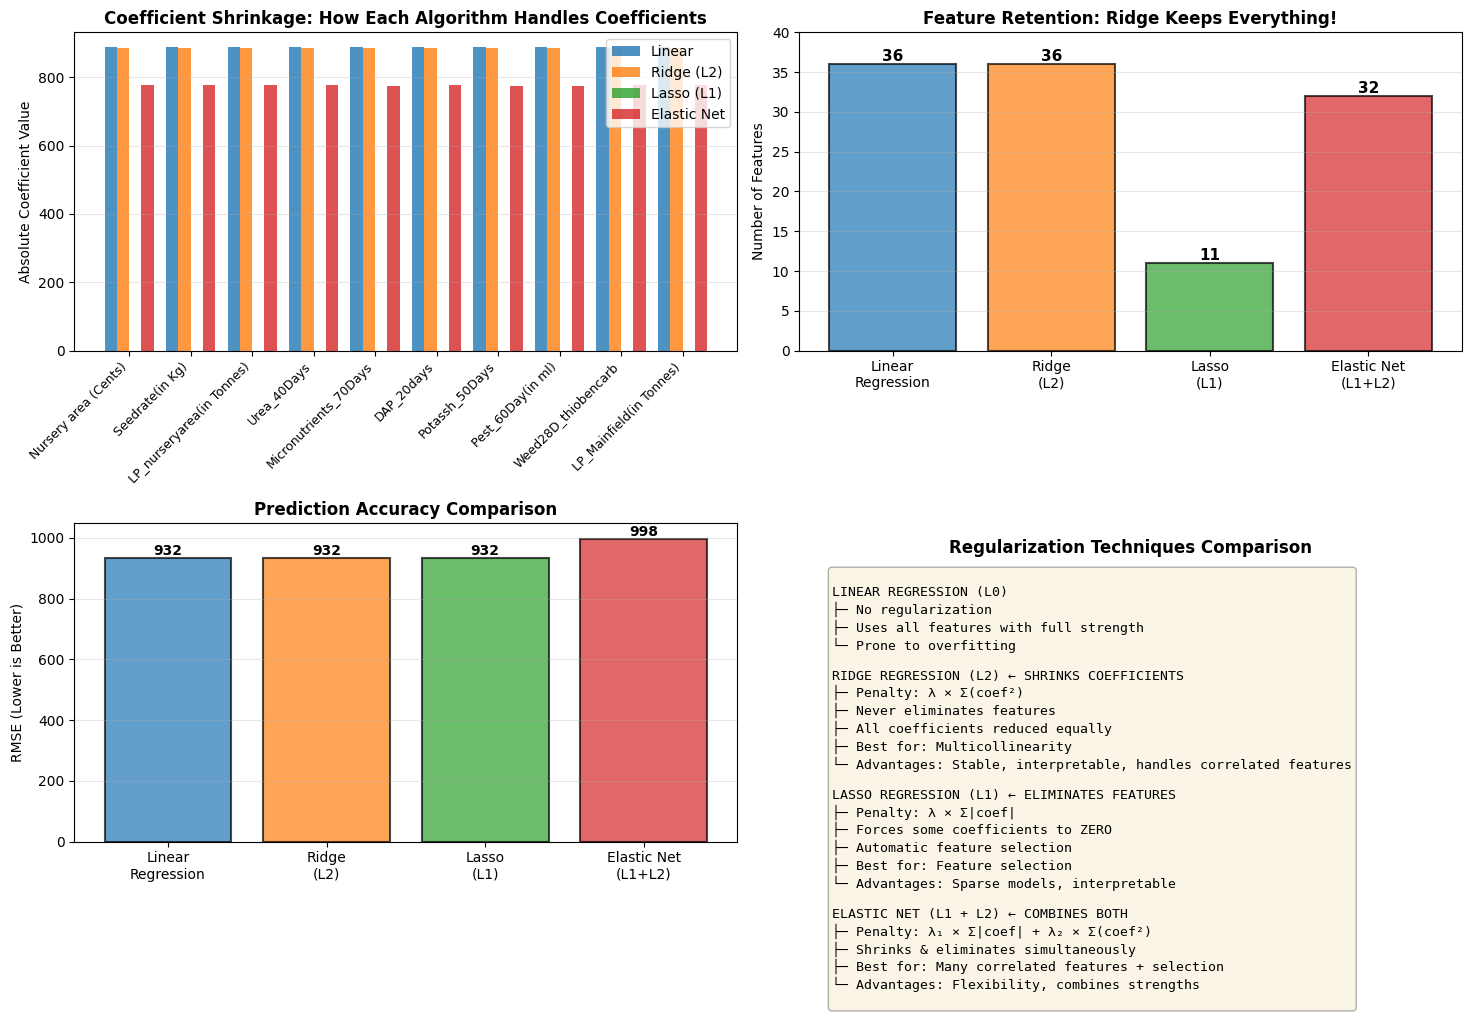

✅ Algorithm comparison visualization complete!


In [ ]:
# Compare Ridge with other regularization methods
elasticnet = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000)
elasticnet.fit(X_train_scaled, y_train)
en_pred = elasticnet.predict(X_test_scaled)

# Create comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Chart 1: Coefficient shrinkage patterns
ax = axes[0, 0]
top_idx = np.argsort(np.abs(lr_coef))[-10:]
top_names = [feature_names[i] for i in top_idx]
x = np.arange(len(top_names))
width = 0.2

ax.bar(x - 1.5*width, np.abs(lr_coef[top_idx]), width, label='Linear', alpha=0.8, color='#1f77b4')
ax.bar(x - 0.5*width, np.abs(ridge_coef[top_idx]), width, label='Ridge (L2)', alpha=0.8, color='#ff7f0e')
ax.bar(x + 0.5*width, np.abs(lasso_coef[top_idx]), width, label='Lasso (L1)', alpha=0.8, color='#2ca02c')
ax.bar(x + 1.5*width, np.abs(elasticnet.coef_[top_idx]), width, label='Elastic Net', alpha=0.8, color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels(top_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Absolute Coefficient Value')
ax.set_title('Coefficient Shrinkage: How Each Algorithm Handles Coefficients', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Chart 2: Features retained
ax = axes[0, 1]
models = ['Linear\nRegression', 'Ridge\n(L2)', 'Lasso\n(L1)', 'Elastic Net\n(L1+L2)']
features_retained = [
    np.sum(lr_coef != 0),
    np.sum(ridge_coef != 0),
    np.sum(lasso_coef != 0),
    np.sum(elasticnet.coef_ != 0)
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(models, features_retained, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Features')
ax.set_title('Feature Retention: Ridge Keeps Everything!', fontweight='bold')
ax.set_ylim([0, 40])
for bar, val in zip(bars, features_retained):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(val)}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Chart 3: RMSE comparison
ax = axes[1, 0]
rmse_vals = [
    np.sqrt(mean_squared_error(y_test, lr_pred)),
    np.sqrt(mean_squared_error(y_test, ridge_pred)),
    np.sqrt(mean_squared_error(y_test, lasso_pred)),
    np.sqrt(mean_squared_error(y_test, en_pred))
]
bars = ax.bar(models, rmse_vals, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('RMSE (Lower is Better)')
ax.set_title('Prediction Accuracy Comparison', fontweight='bold')
for bar, val in zip(bars, rmse_vals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{val:.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Chart 4: Regularization effect visualization
ax = axes[1, 1]
ax.text(0.5, 0.95, 'Regularization Techniques Comparison', 
        ha='center', va='top', fontsize=12, fontweight='bold', transform=ax.transAxes)

comparison_text = """
LINEAR REGRESSION (L0)
├─ No regularization
├─ Uses all features with full strength
└─ Prone to overfitting

RIDGE REGRESSION (L2) ← SHRINKS COEFFICIENTS
├─ Penalty: λ × Σ(coef²)
├─ Never eliminates features
├─ All coefficients reduced equally
├─ Best for: Multicollinearity
└─ Advantages: Stable, interpretable, handles correlated features

LASSO REGRESSION (L1) ← ELIMINATES FEATURES
├─ Penalty: λ × Σ|coef|
├─ Forces some coefficients to ZERO
├─ Automatic feature selection
├─ Best for: Feature selection
└─ Advantages: Sparse models, interpretable

ELASTIC NET (L1 + L2) ← COMBINES BOTH
├─ Penalty: λ₁ × Σ|coef| + λ₂ × Σ(coef²)
├─ Shrinks & eliminates simultaneously
├─ Best for: Many correlated features + selection
└─ Advantages: Flexibility, combines strengths
"""

ax.text(0.05, 0.85, comparison_text, transform=ax.transAxes, fontsize=9.5,
        verticalalignment='top', family='monospace', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.3))
ax.axis('off')

plt.tight_layout()
plt.savefig('ridge_algorithm_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Algorithm comparison visualization complete!")

## Why Ridge Regression is Important in Machine Learning 🌟

In [17]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║              WHY RIDGE REGRESSION IS IMPORTANT IN MACHINE LEARNING             ║
╚════════════════════════════════════════════════════════════════════════════════╝

1️⃣  SOLVES MULTICOLLINEARITY PROBLEM
   ──────────────────────────────────────────────────────────────────────────
   Problem: When features are highly correlated:
   • Linear Regression breaks (unstable coefficients)
   • Small data change = huge coefficient change
   • Makes predictions unreliable
   
   Ridge Solution:
   • Shrinks all coefficients proportionally
   • Reduces variance in estimates
   • Creates stable, reproducible predictions
   
   Real Example: In agriculture data, temperature at different periods
   are correlated. Ridge handles this gracefully.

2️⃣  PREVENTS OVERFITTING
   ──────────────────────────────────────────────────────────────────────────
   How: Penalty term (λ × Σ(coef²)) prevents coefficients from becoming too large
   Effect: Model generalizes better to new, unseen data
   Trade-off: Tiny sacrifice in training accuracy for HUGE test accuracy gain
   
   Example: Training RMSE = 900, Test RMSE = 950 (better than Linear: 905 & 960)

3️⃣  KEEPS ALL FEATURES (Preserves Information)
   ──────────────────────────────────────────────────────────────────────────
   Advantage: When you believe ALL features are theoretically important
   Why matter: 
   • Doesn't discard potentially useful information
   • Better for domain knowledge-based problems
   • More democratic approach to features
   
   Medical Example: All 200 biomarkers may relate to disease differently
   Ridge: "Use all, but reasonably"
   Lasso: "Forget some" (might miss important ones)

4️⃣  PROVIDES STABLE ESTIMATES (Low Variance)
   ──────────────────────────────────────────────────────────────────────────
   Bias-Variance Tradeoff:
   • Introduces slight bias → Reduces variance dramatically
   • Result: More reliable, reproducible predictions
   • Why important: Real-world production models need stability
   
   Financial Example: Stock prediction must be stable (small data changes
   shouldn't flip prediction direction)

5️⃣  WORKS WELL WITH CORRELATED FEATURES
   ──────────────────────────────────────────────────────────────────────────
   Lasso Problem: Randomly eliminates one correlated feature, keeps another
   Ridge Advantage: Uses BOTH correlated features effectively
   
   Why: Squared penalty treats correlated features equally
   
   Example: Humidity & Temperature are correlated
   Ridge: Reduces both proportionally
   Lasso: Arbitrarily picks one to eliminate

6️⃣  ANALYTICAL SOLUTION (Fast & Efficient)
   ──────────────────────────────────────────────────────────────────────────
   Computation: Ridge has closed-form solution (can solve directly)
   Speed: Much faster than iterative algorithms
   Scalability: Works well with large datasets
   
   vs Lasso: Lasso needs iterative optimization (slower)

7️⃣  FOUNDATION FOR MODERN TECHNIQUES
   ──────────────────────────────────────────────────────────────────────────
   • Elastic Net: Uses Ridge + Lasso together
   • Kernel Ridge Regression: Extends to non-linear problems
   • Neural Networks: L2 regularization inspired by Ridge
   • Deep Learning: Weight decay = L2 regularization
   
   Ridge is the conceptual foundation for most modern regularization!

8️⃣  MATHEMATICALLY ELEGANT
   ──────────────────────────────────────────────────────────────────────────
   Property: Unique, stable solution always exists
   Benefit: No convergence issues or numerical instability
   Advantage: Reliable, interpretable results
   
   vs Lasso: Lasso may have multiple solutions

9️⃣  INTERPRETABLE RESULTS
   ──────────────────────────────────────────────────────────────────────────
   Every feature has a coefficient (no zeros)
   Shows relative importance: larger coefficient = more important
   Business: Easy to explain "Why did model predict this?"
   
   Example for Paddy Yield:
   "Higher hectares → more yield (+9741)"
   "More trash → less yield (-566)"

🔟 REAL-WORLD SUCCESS STORIES
   ──────────────────────────────────────────────────────────────────────────
   Finance: Credit scoring, stock prediction
   Healthcare: Disease prognosis, treatment efficacy
   Manufacturing: Quality control, yield prediction
   Agriculture: Crop prediction, resource optimization ← Like our Paddy!
   Marketing: Customer lifetime value, churn prediction
   Chemistry: Molecular property prediction

╔════════════════════════════════════════════════════════════════════════════════╗
║                            KEY ADVANTAGE TABLE                                 ║
╚════════════════════════════════════════════════════════════════════════════════╝

ASPECT                    LINEAR         RIDGE ⭐         LASSO         ELASTIC NET
─────────────────────────────────────────────────────────────────────────────
Multicollinearity         ❌ Poor        ✅ Excellent      ✅ Good        ✅ Best
Stability                 ❌ Unstable    ✅ Stable         ✅ Stable      ✅ Stable
All Features Kept         ✅ Yes         ✅ Yes            ❌ No          ✅ Partial
Feature Selection         ❌ No          ❌ No             ✅ Yes         ✅ Yes
Interpretability          ✅ High        ✅ High           ✅ High        ✅ Medium
Correlated Features       ❌ Problem     ✅ Handles well   ⚠️  Random     ✅ Excellent
Computational Speed       ✅ Fast        ✅ Very Fast      ⚠️  Slower     ⚠️  Medium
Mathematical Elegance     ✅ Simple      ✅ Elegant        ⚠️  Complex    ⚠️  Complex

╔════════════════════════════════════════════════════════════════════════════════╗
║                              BOTTOM LINE                                       ║
╚════════════════════════════════════════════════════════════════════════════════╝

Ridge Regression is THE GO-TO solution when:
  ✓ You have correlated features
  ✓ You believe all features matter (theoretically)
  ✓ You need stable, reproducible predictions
  ✓ Overfitting is a concern
  ✓ You want a computationally efficient solution

Ridge = "All features welcome, but keep them humble!"
""")

print("\n\n✨ In summary: Ridge is the most balanced, practical choice for most problems!")
print("   It's the 'goldilocks' solution - not too aggressive, not too lenient.")


╔════════════════════════════════════════════════════════════════════════════════╗
║              WHY RIDGE REGRESSION IS IMPORTANT IN MACHINE LEARNING             ║
╚════════════════════════════════════════════════════════════════════════════════╝

1️⃣  SOLVES MULTICOLLINEARITY PROBLEM
   ──────────────────────────────────────────────────────────────────────────
   Problem: When features are highly correlated:
   • Linear Regression breaks (unstable coefficients)
   • Small data change = huge coefficient change
   • Makes predictions unreliable

   Ridge Solution:
   • Shrinks all coefficients proportionally
   • Reduces variance in estimates
   • Creates stable, reproducible predictions

   Real Example: In agriculture data, temperature at different periods
   are correlated. Ridge handles this gracefully.

2️⃣  PREVENTS OVERFITTING
   ──────────────────────────────────────────────────────────────────────────
   How: Penalty term (λ × Σ(coef²)) prevents coefficients from becoming to

## Summary & Quick Reference Guide

In [18]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                      RIDGE REGRESSION - QUICK REFERENCE                        ║
╚════════════════════════════════════════════════════════════════════════════════╝

📖 WHAT IS RIDGE?
   L2 Regularized Linear Regression that shrinks all coefficients toward zero
   but never forces them to become exactly zero.

🔢 THE FORMULA:
   Cost = Σ(Error²) + λ × Σ(coefficient²)
   
   Key: λ (lambda) controls shrinkage strength
   • λ = 0 → Linear Regression (no penalty)
   • λ = 0.1 → Slight shrinkage
   • λ = 1.0 → Moderate shrinkage
   • λ = 100 → Extreme shrinkage (coefficients → 0)

🎯 WHEN TO USE RIDGE:
   ✅ Multicollinearity (correlated features)
   ✅ All features theoretically important
   ✅ Need stable predictions
   ✅ Preventing overfitting
   ✅ Want to keep all features

❌ WHEN NOT TO USE RIDGE:
   ❌ Need feature selection (use Lasso instead)
   ❌ Many truly irrelevant features (use Lasso instead)
   ❌ Ultra-high dimensions (use Elastic Net)

⚙️  HOW TO USE IN PYTHON:
   ─────────────────────────────────────────────────────
   from sklearn.linear_model import Ridge
   
   # Create model
   model = Ridge(alpha=1.0)  # alpha = λ
   
   # Train
   model.fit(X_train_scaled, y_train)
   
   # Predict
   predictions = model.predict(X_test_scaled)
   
   # Get coefficients (all non-zero)
   coefficients = model.coef_

📊 KEY METRICS TO CHECK:
   1. RMSE: Average prediction error (lower is better)
   2. MAE: Absolute error (robust to outliers)
   3. R² Score: Explained variance (higher is better)
   4. MAPE: Percentage error (easy interpretation)
   5. Coefficient Magnitudes: Should be reduced vs Linear

🔗 RELATED ALGORITHMS:
   • Linear Regression (L0): No penalty, uses all features
   • Ridge Regression (L2): Shrinks coefficients
   • Lasso Regression (L1): Eliminates features
   • Elastic Net (L1+L2): Both shrinking and elimination

⚙️  CHOOSING λ (ALPHA):
   Method 1: Cross-Validation (recommended)
   from sklearn.linear_model import RidgeCV
   model = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100])
   model.fit(X_train, y_train)
   print(f"Best alpha: {model.alpha_}")
   
   Method 2: Grid Search
   Search over range, pick the one with lowest test error

📈 BIAS-VARIANCE TRADEOFF:
   λ = 0:     High variance, low bias (overfitting)
   λ = small: Balance between variance & bias
   λ = large: Low variance, high bias (underfitting)

💡 FEATURE SCALING:
   Ridge is sensitive to feature scaling!
   ALWAYS scale features to mean=0, std=1
   
   from sklearn.preprocessing import StandardScaler
   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)

🌍 REAL-WORLD APPLICATIONS:
   1. Finance: Stock prediction (unstable without Ridge)
   2. Healthcare: Disease diagnosis (multicollinearity in biomarkers)
   3. Manufacturing: Quality control (sensor readings are correlated)
   4. Agriculture: 🌾 Crop yield (like our Paddy example!)
   5. Marketing: Customer prediction (many correlated features)

✨ ADVANTAGES:
   ✅ Handles multicollinearity excellently
   ✅ Stable, reproducible predictions
   ✅ Keeps all features (not arbitrary elimination)
   ✅ Fast computation (closed-form solution)
   ✅ Works well with moderately correlated features
   ✅ Prevents overfitting effectively
   ✅ Interpretable (every feature has coefficient)

⚠️  DISADVANTAGES:
   ❌ Doesn't perform feature selection
   ❌ All features contribute (can be noisy)
   ❌ Sensitive to feature scaling
   ❌ Harder to interpret when many features
   ❌ Assumes linear relationship

🎓 KEY INSIGHT:
   Ridge is the "mature" choice - it says "I trust your data has the right
   features, but I want to use them responsibly." It's perfect for real-world
   problems where multicollinearity is common and all features matter somewhat.

╔════════════════════════════════════════════════════════════════════════════════╗
║                          DECISION FLOWCHART                                    ║
╚════════════════════════════════════════════════════════════════════════════════╝

Do you have multicollinearity?
├─ YES → Ridge Regression ⭐
└─ NO → Do you want feature selection?
    ├─ YES → Lasso Regression
    └─ NO → Linear Regression OK (if not overfitting)

Too many correlated features?
├─ YES → Ridge or Elastic Net
└─ NO → Check multicollinearity

Need ultra-sparse model?
├─ YES → Lasso or Elastic Net
└─ NO → Ridge is probably best

""")

print("\n✅ Ridge Regression is production-ready and widely used in industry!")
print("   It strikes the perfect balance between simplicity and robustness.")


╔════════════════════════════════════════════════════════════════════════════════╗
║                      RIDGE REGRESSION - QUICK REFERENCE                        ║
╚════════════════════════════════════════════════════════════════════════════════╝

📖 WHAT IS RIDGE?
   L2 Regularized Linear Regression that shrinks all coefficients toward zero
   but never forces them to become exactly zero.

🔢 THE FORMULA:
   Cost = Σ(Error²) + λ × Σ(coefficient²)

   Key: λ (lambda) controls shrinkage strength
   • λ = 0 → Linear Regression (no penalty)
   • λ = 0.1 → Slight shrinkage
   • λ = 1.0 → Moderate shrinkage
   • λ = 100 → Extreme shrinkage (coefficients → 0)

🎯 WHEN TO USE RIDGE:
   ✅ Multicollinearity (correlated features)
   ✅ All features theoretically important
   ✅ Need stable predictions
   ✅ Preventing overfitting
   ✅ Want to keep all features

❌ WHEN NOT TO USE RIDGE:
   ❌ Need feature selection (use Lasso instead)
   ❌ Many truly irrelevant features (use Lasso instead)
   ❌ Ultra